<a href="https://colab.research.google.com/github/kaashvi5/Amazon_ML_Summer_School/blob/main/Amazon_Summer_School_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score

In [44]:
df = pd.read_csv("places.csv")

In [45]:
print(df.shape)

(1000, 49)


In [46]:
df.head()

,place_id,place_name,category,city,state,latitude,longitude,rating,review_count,price_range,...,user_age_group,user_budget_preference,user_preferred_category,user_accessibility_need,interaction_type,user_rating_given,visit_frequency,time_spent_minutes,would_revisit,timestamp
0,PL0001,The Daily Grind - Delhi,Cafe,Delhi,Delhi,28.606722,77.263783,4.8,2440,Moderate,...,35-44,Premium,Cafe,NaN,viewed,NaN,NaN,1,NaN,6/1/2024 13:49
1,PL0002,Caffeine Quarters - Noida,Cafe,Noida,Uttar Pradesh,28.645983,77.464052,2.4,3400,Moderate,...,45-54,Premium,Bookstore,NaN,viewed,NaN,NaN,1,NaN,8/1/2024 18:46
2,PL0003,Aromas Coffee House - Ghaziabad,Cafe,Ghaziabad,Uttar Pradesh,28.609207,77.357947,3.9,1449,Premium,...,55+,Budget,Cafe,NaN,viewed,NaN,NaN,3,NaN,10/12/2024 21:39
3,PL0004,Kaleidoscope Coffee - Gurugram,Cafe,Gurugram,Haryana,28.501127,77.082813,4.1,1963,Moderate,...,35-44,Premium,Library,Hearing Impaired,viewed,NaN,NaN,1,NaN,1/26/2023 21:21
4,PL0005,Monsoon Cafe - Mumbai,Cafe,Mumbai,Maharashtra,19.029787,72.977641,3.7,3489,Moderate,...,55+,Premium,Cafe,Hearing Impaired,visited,5.0,occasional,48,yes,10/16/2023 13:32


In [47]:
features = [
    "category",
    "city",
    "price_range",
    "indoor_outdoor",
    "crowd_level",
    "wheelchair_accessible",
    "ramp_available",
    "accessible_washroom",
    "elevator_available",
    "family_friendly",
    "study_friendly",
    "work_friendly",
    "tags"
]

## **Handling Missing Values**

In [48]:
for col in features:
    df[col] = df[col].fillna("")

## **Create combined features**

In [49]:
df["combined_features"] = ""

for col in features:
    df["combined_features"] += df[col].astype(str) + " "

## **Vectorize Text**

In [50]:
df["combined_features"] = df.astype(str).agg(" ".join, axis=1)

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
feature_matrix = vectorizer.fit_transform(df["combined_features"])

In [52]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(feature_matrix)

In [53]:
def recommend(place_name):

    if place_name not in df["place_name"].values:
        print("Place not found!")
        return

    idx = df[df["place_name"] == place_name].index[0]

    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print("Recommended Places:\n")

    for place in scores[1:6]:
        print(df.iloc[place[0]]["place_name"])

## **Improved Recommendation Function**

In [54]:
def recommend(place_name, top_n=10):

    if place_name not in df["place_name"].values:
        print("Place not found!")
        return

    idx = df[df["place_name"] == place_name].index[0]

    sim_scores = similarity[idx]

    recommendations = []

    for i in range(len(df)):

        if i == idx:
            continue

        score = sim_scores[i]

        # Rating weight
        score += df.iloc[i]["rating"] * 0.10

        # Accessibility weight
        score += df.iloc[i]["accessibility_score"] * 0.15

        # Review count weight
        score += np.log1p(df.iloc[i]["review_count"]) * 0.05

        recommendations.append((i, score))

    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    print("\nTop Recommendations\n")

    for i, score in recommendations[:top_n]:

        print(
            f"{df.iloc[i]['place_name']} | "
            f"Rating: {df.iloc[i]['rating']} | "
            f"Accessibility: {df.iloc[i]['accessibility_score']} | "
            f"Score: {round(score,2)}"
        )

## **Personalized User Recommendations**

In [55]:
def recommend_for_user(
        city,
        category,
        wheelchair_needed=True,
        budget="Medium",
        top_n=10):

    filtered = df.copy()

    filtered = filtered[
        filtered["city"] == city
    ]

    filtered = filtered[
        filtered["category"] == category
    ]

    if wheelchair_needed:
        filtered = filtered[
            filtered["wheelchair_accessible"] == "Yes"
        ]

    filtered["final_score"] = (
        filtered["rating"] * 0.4
        +
        filtered["accessibility_score"] * 0.4
        +
        np.log1p(filtered["review_count"]) * 0.2
    )

    return filtered.sort_values(
        by="final_score",
        ascending=False
    ).head(top_n)

## **Add Evaluation**

In [56]:
from sklearn.metrics import mean_absolute_error

actual = df["rating"]

predicted = actual.mean()

predictions = [predicted] * len(actual)

mae = mean_absolute_error(
    actual,
    predictions
)

print("MAE:", mae)

MAE: 0.7390384000000001


# **Testing**

In [57]:
print(df["place_name"].head(10).tolist())

['The Daily Grind - Delhi', 'Caffeine Quarters - Noida', 'Aromas Coffee House - Ghaziabad', 'Kaleidoscope Coffee - Gurugram', 'Monsoon Cafe - Mumbai', 'Ground Up Cafe - Pune', 'Bean There Cafe - Bengaluru', 'Caffeine Quarters - Hyderabad', 'Roastery Coffee House - Chennai', 'Barista Lavazza - Kolkata']


In [58]:
recommend("The Daily Grind - Delhi")


Top Recommendations

Barista Lavazza - Ghaziabad | Rating: 4.6 | Accessibility: 9.3 | Score: 2.75
Bangalore International Centre - Delhi | Rating: 4.6 | Accessibility: 9.3 | Score: 2.71
BHIVE Workspace - Jaipur | Rating: 4.9 | Accessibility: 9.9 | Score: 2.68
Ravindra Bharathi Hyderabad - Bengaluru | Rating: 4.0 | Accessibility: 10.0 | Score: 2.68
INOX Insignia - Ghaziabad | Rating: 4.2 | Accessibility: 10.0 | Score: 2.64
South City Mall - Delhi | Rating: 4.4 | Accessibility: 8.9 | Score: 2.63
Gachibowli Athletic Stadium - Delhi | Rating: 4.1 | Accessibility: 9.3 | Score: 2.62
Seawoods Grand Central - Delhi | Rating: 4.6 | Accessibility: 8.8 | Score: 2.6
Mukta A2 Cinemas - Hyderabad | Rating: 3.7 | Accessibility: 9.8 | Score: 2.59
NSCI Dome Mumbai - Delhi | Rating: 5.0 | Accessibility: 8.1 | Score: 2.59


In [59]:
recommend_for_user(
    city="Delhi",
    category="Cafe",
    wheelchair_needed=True
)

,place_id,place_name,category,city,state,latitude,longitude,rating,review_count,price_range,...,user_preferred_category,user_accessibility_need,interaction_type,user_rating_given,visit_frequency,time_spent_minutes,would_revisit,timestamp,combined_features,final_score
60,PL0061,Sip & Savor - Delhi,Cafe,Delhi,Delhi,28.637681,77.222491,3.5,8346,Moderate,...,Cafe,Family with Kids,saved,NaN,NaN,5,NaN,10/24/2023 11:20,PL0061 Sip & Savor - Delhi Cafe Delhi Delhi 28...,6.205931
0,PL0001,The Daily Grind - Delhi,Cafe,Delhi,Delhi,28.606722,77.263783,4.8,2440,Moderate,...,Cafe,NaN,viewed,NaN,NaN,1,NaN,6/1/2024 13:49,PL0001 The Daily Grind - Delhi Cafe Delhi Delh...,6.120033
12,PL0013,Kaleidoscope Coffee - Delhi,Cafe,Delhi,Delhi,28.632368,77.144323,3.4,9165,Moderate,...,Cafe,Hearing Impaired,rated,5.0,occasional,142,yes,2/3/2024 15:05,PL0013 Kaleidoscope Coffee - Delhi Cafe Delhi ...,5.504651
24,PL0025,Pebble Street Cafe - Delhi,Cafe,Delhi,Delhi,28.681360,77.190065,3.8,3773,Premium,...,Cafe,NaN,visited,5.0,first_time,129,yes,6/22/2023 9:59,PL0025 Pebble Street Cafe - Delhi Cafe Delhi D...,5.447178
48,PL0049,Barista Lavazza - Delhi,Cafe,Delhi,Delhi,28.618647,77.322685,4.1,68,Budget,...,Cafe,Elderly,clicked,NaN,NaN,7,NaN,10/4/2023 18:25,PL0049 Barista Lavazza - Delhi Cafe Delhi Delh...,4.606821


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create target column
y = (df["accessibility_score"] >= 7).astype(int)

# Features
X = df[
    [
        "rating",
        "review_count",
        "distance_from_metro_km",
        "distance_from_bus_stop_km",
        "safety_score",
        "cleanliness_score",
        "service_score",
        "ambience_score"
    ]
]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

# Detailed Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8
Precision: 0.6667
Recall   : 0.6207
F1 Score : 0.6429

Confusion Matrix
[[124  18]
 [ 22  36]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       142
           1       0.67      0.62      0.64        58

    accuracy                           0.80       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.80      0.80      0.80       200



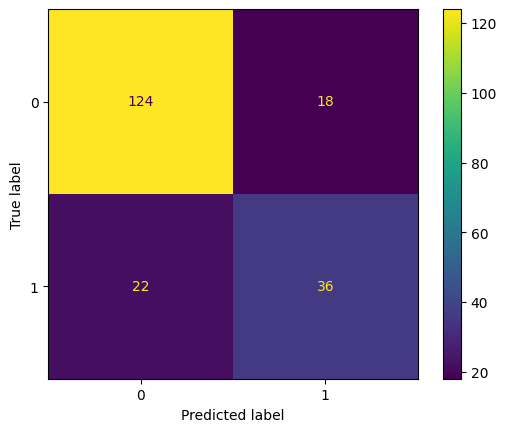

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()

## **Accessibility Score Distribution**

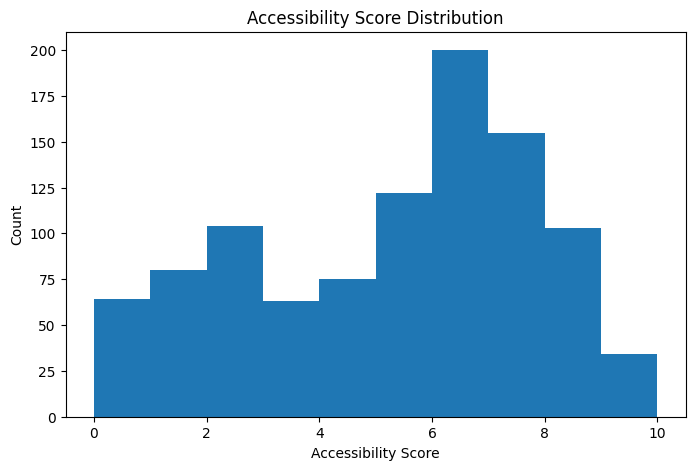

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["accessibility_score"], bins=10)
plt.title("Accessibility Score Distribution")
plt.xlabel("Accessibility Score")
plt.ylabel("Count")
plt.show()

## **Top Cities by Number of Places**

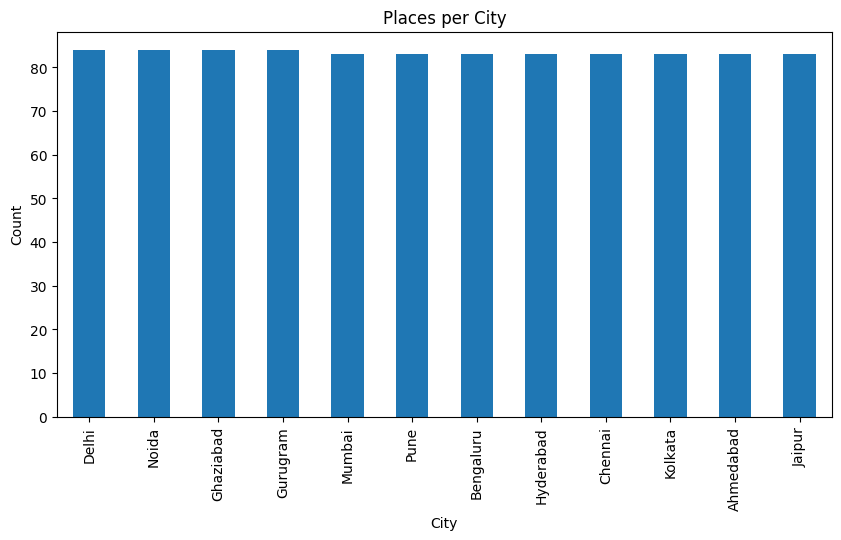

In [63]:
df["city"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Places per City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

## **Average Rating by Category**

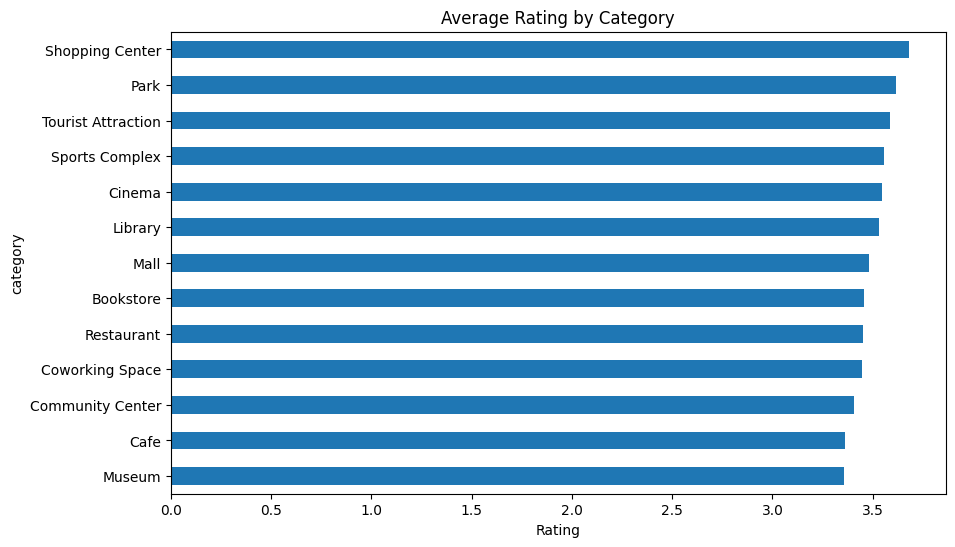

In [64]:
category_rating = df.groupby(
    "category"
)["rating"].mean()

category_rating.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Average Rating by Category")
plt.xlabel("Rating")
plt.show()

## **Accessibility Score vs Rating**

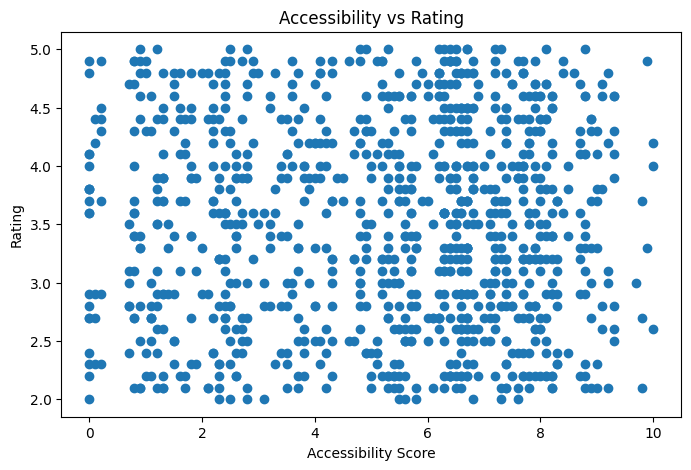

In [65]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["accessibility_score"],
    df["rating"]
)

plt.xlabel("Accessibility Score")
plt.ylabel("Rating")
plt.title("Accessibility vs Rating")

plt.show()

## **Wheelchair Accessible Places**

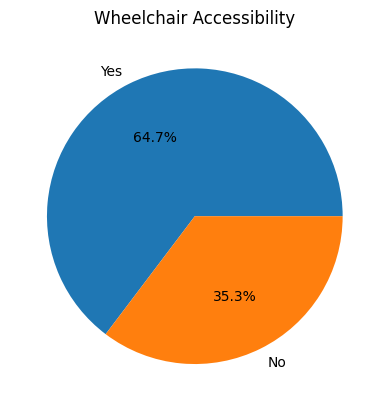

In [66]:
df["wheelchair_accessible"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Wheelchair Accessibility")
plt.ylabel("")
plt.show()

## **Correlation Heatmap**

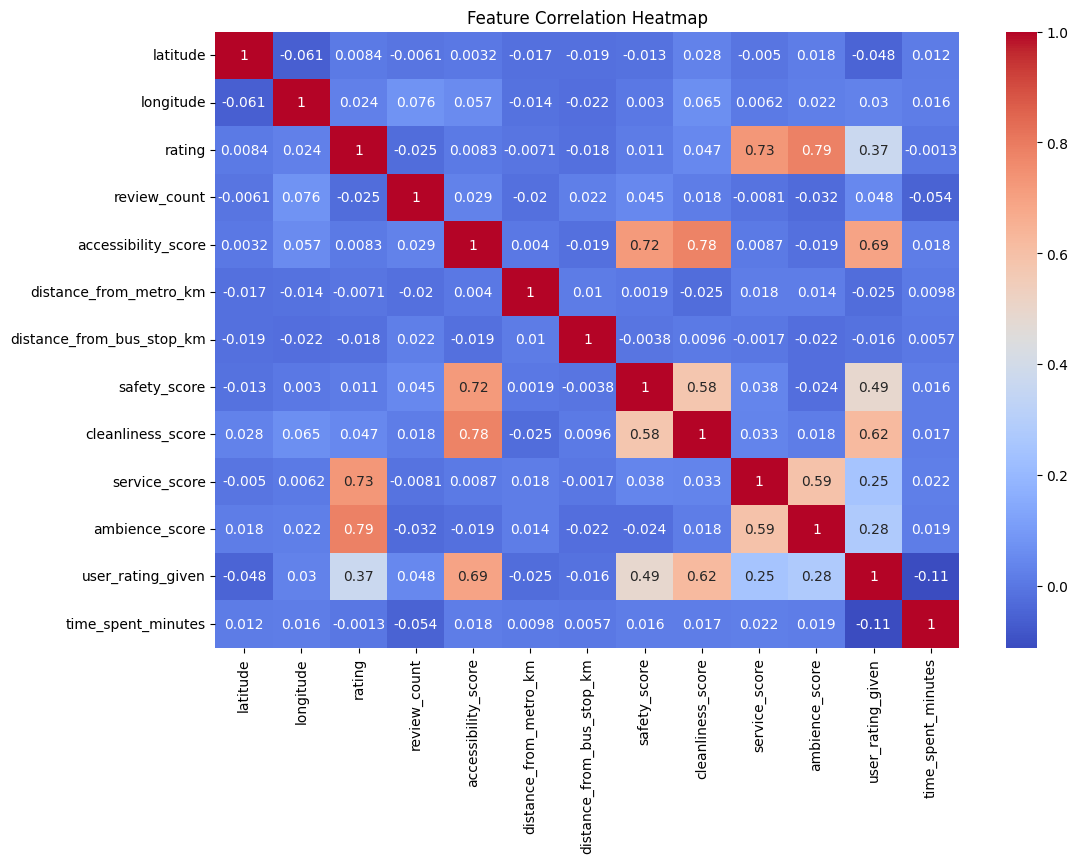

In [67]:
import seaborn as sns

numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

## **Top 10 Highest Rated Places**

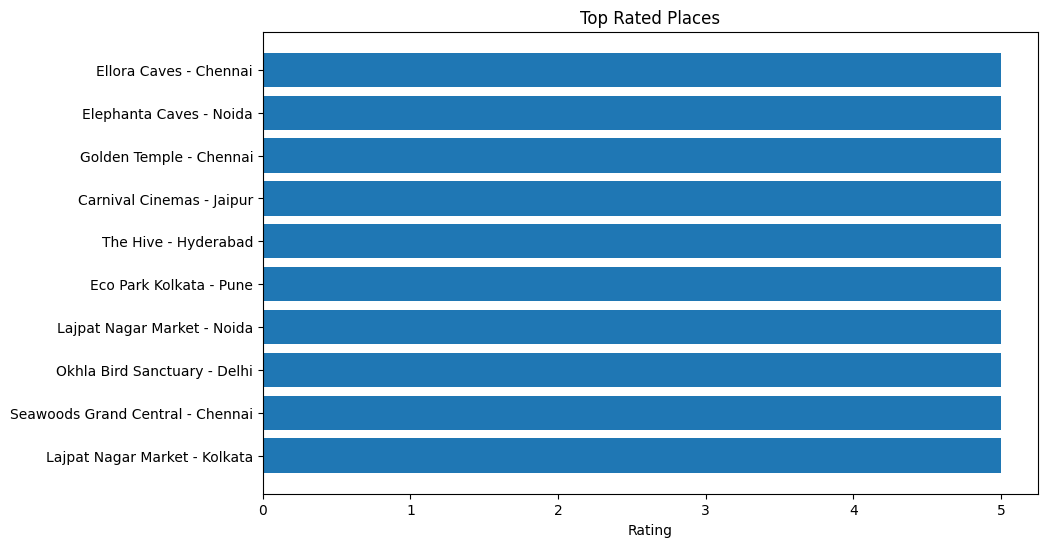

In [68]:
top_places = df.sort_values(
    "rating",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_places["place_name"],
    top_places["rating"]
)

plt.title("Top Rated Places")
plt.xlabel("Rating")
plt.show()

## **Feature Importance**

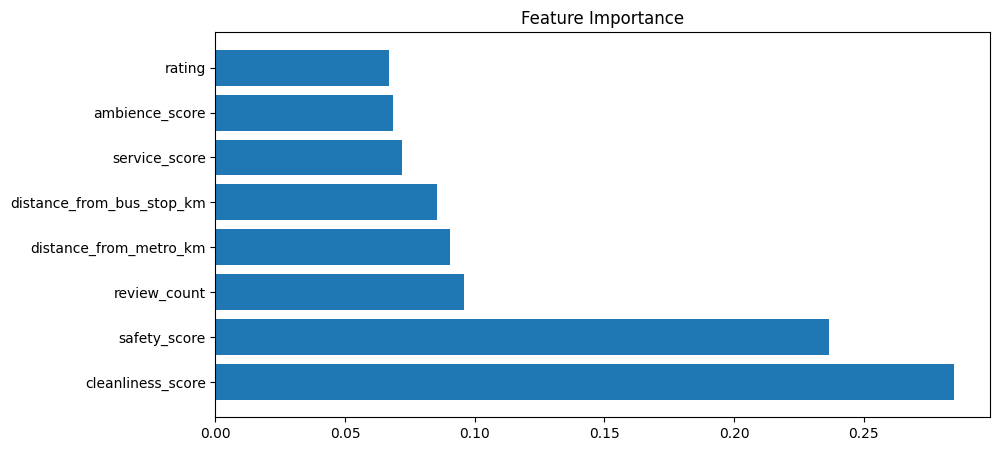

In [69]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.show()

### **Recommendation Quality Evaluationa**

In [70]:
def precision_at_k(recommended, relevant, k=5):
    recommended = recommended[:k]
    hits = len(set(recommended) & set(relevant))
    return hits / k

In [78]:
recommended = [
    "Place A",
    "Place B",
    "Place C",
    "Place D",
    "Place E"
]

relevant = [
    "Place A",
    "Place C",
    "Place F"
]

print("Precision@5:",
      precision_at_k(
          recommended,
          relevant,
          5
      ))

Precision@5: 0.4


## **Saving Models**

In [72]:
import joblib

joblib.dump(model, "accessibility_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

## **Feature Importance Table**

In [73]:
importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
5,cleanliness_score,0.284594
4,safety_score,0.236580
1,review_count,0.096018
2,distance_from_metro_km,0.090239
3,distance_from_bus_stop_km,0.085333
6,service_score,0.071806
7,ambience_score,0.068537
0,rating,0.066894


### **User Input Prediction**

In [74]:
sample = pd.DataFrame({
    "rating":[4.5],
    "review_count":[1000],
    "distance_from_metro_km":[0.5],
    "distance_from_bus_stop_km":[0.2],
    "safety_score":[9],
    "cleanliness_score":[8],
    "service_score":[9],
    "ambience_score":[8]
})

prediction = model.predict(sample)

print(prediction)

[1]


### **BOXPLOT**

<Axes: xlabel='category', ylabel='rating'>

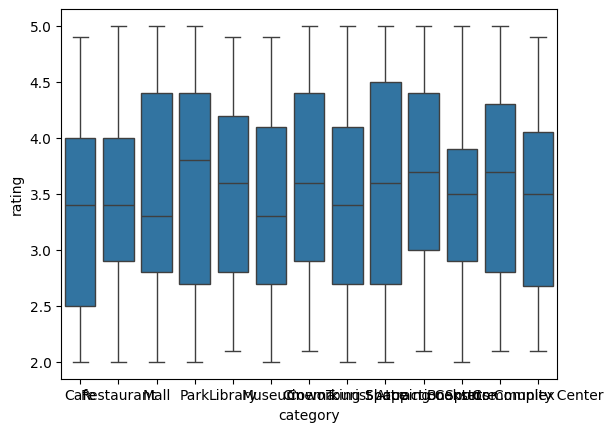

In [75]:
sns.boxplot(
    x="category",
    y="rating",
    data=df
)

### **COUNTPLOT**

<Axes: xlabel='crowd_level', ylabel='count'>

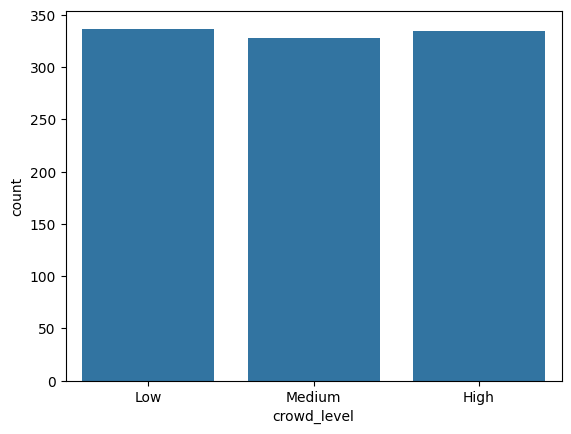

In [76]:
sns.countplot(
    x="crowd_level",
    data=df
)

### **SCATTERPLOT**

<Axes: xlabel='review_count', ylabel='rating'>

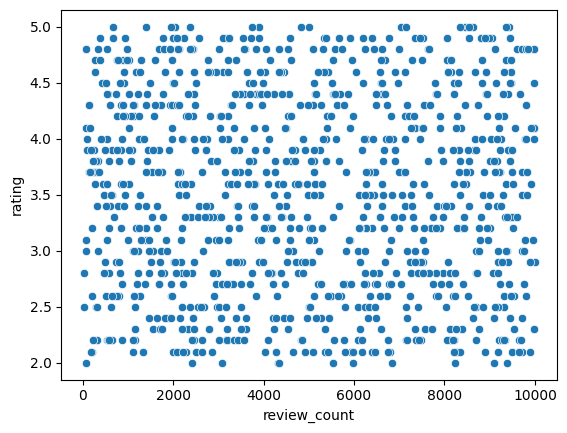

In [77]:
sns.scatterplot(
    x="review_count",
    y="rating",
    data=df
)

# **Conclusion**

In [79]:
print("""
Project Summary

1. Built an Accessible Hangout Recommender System.
2. Applied TF-IDF and Cosine Similarity for recommendations.
3. Built a Random Forest accessibility classifier.
4. Performed data cleaning and feature engineering.
5. Evaluated model using Accuracy, Precision, Recall and F1 Score.
6. Visualized insights using EDA and Feature Importance.
""")


Project Summary

1. Built an Accessible Hangout Recommender System.
2. Applied TF-IDF and Cosine Similarity for recommendations.
3. Built a Random Forest accessibility classifier.
4. Performed data cleaning and feature engineering.
5. Evaluated model using Accuracy, Precision, Recall and F1 Score.
6. Visualized insights using EDA and Feature Importance.



In [81]:
# Future Improvements

# - Real-time Google Maps integration
# - User authentication
# - Collaborative filtering
# - Hybrid recommendation system
# - Streamlit deployment